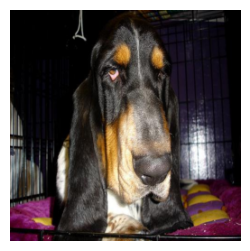

Index 54  pred: 1   label: 1


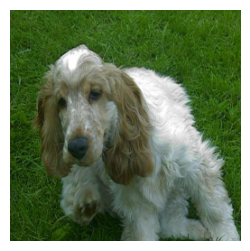

Index 34  pred: 1   label: 1


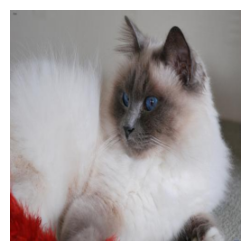

Index 16  pred: 0   label: 0


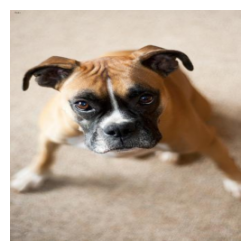

Index 40  pred: 1   label: 1


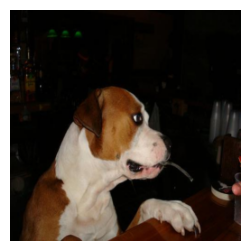

Index 59  pred: 1   label: 1


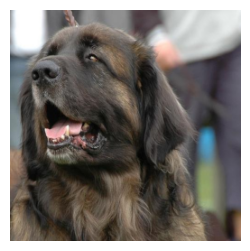

Index 44  pred: 1   label: 1


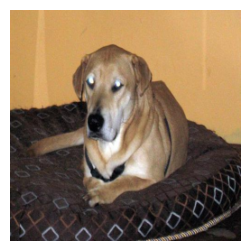

Index 53  pred: 1   label: 1


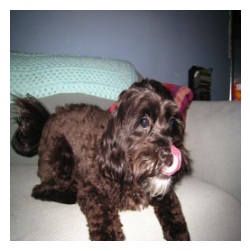

Index 42  pred: 1   label: 1


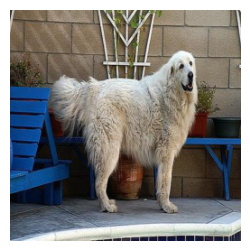

Index 29  pred: 1   label: 1


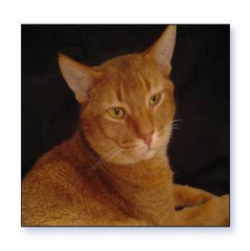

Index 7  pred: 0   label: 0


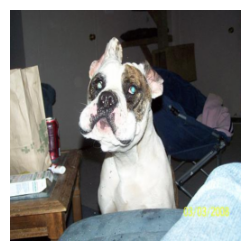

Index 69  pred: 1   label: 1


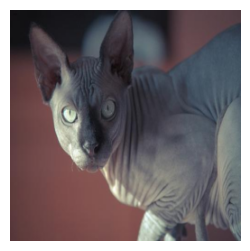

Index 19  pred: 0   label: 0


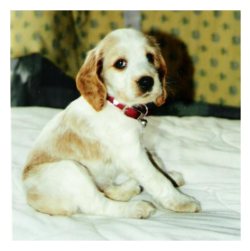

Index 60  pred: 1   label: 1


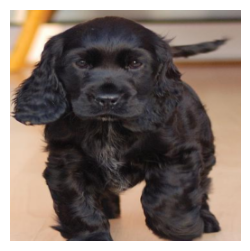

Index 46  pred: 1   label: 1


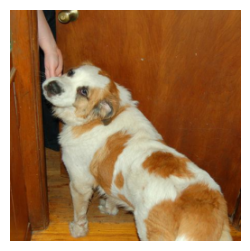

Index 63  pred: 1   label: 1


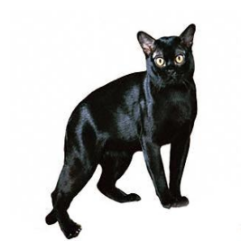

Index 18  pred: 0   label: 0


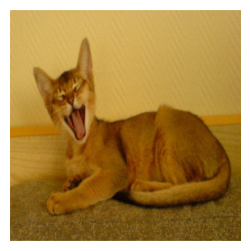

Index 20  pred: 0   label: 0


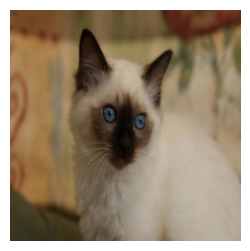

Index 23  pred: 0   label: 0


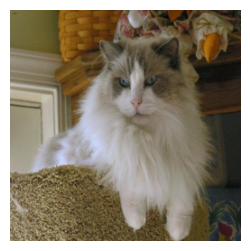

Index 6  pred: 0   label: 0


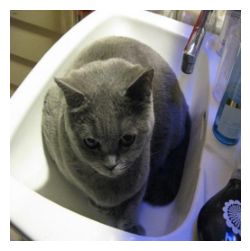

Index 14  pred: 0   label: 0
Displayed 20 images on screen.


In [1]:
from torch.utils.data import DataLoader
import os
import csv
import torch
from torch import nn, optim, utils
import numpy as np
import matplotlib.pyplot as plt
import random
import torchvision
from torchvision.models import ResNet50_Weights
from torchvision.transforms.functional import to_pil_image
from baseline import DatasetLoader
from PIL import Image
from torchvision import transforms


class DataHelper(DatasetLoader):
    def init(self, csv_path):
        super().init(csv_path)
        self.current_dir = os.path.dirname(csv_path)

    def get_image(self, image_path):
        img_path = os.path.join(self.current_dir, "data", image_path)
        image = Image.open(img_path).convert("RGB")
        image_transform = transforms.Compose(
            [
                transforms.Resize((256, 256)),
                transforms.ToTensor(),
            ]
        )
        return image_transform(image)


def get_dataset_length(ds):
    # 优先使用 __len__，否则尝试常见属性，再退化为逐索引检测（直到抛出异常）
    if hasattr(ds, "__len__"):
        try:
            return len(ds)
        except Exception:
            pass

    for attr in ("samples", "imgs", "data"):
        if hasattr(ds, attr):
            try:
                return len(getattr(ds, attr))
            except Exception:
                pass

    i = 0
    try:
        while True:
            _ = ds[i]
            i += 1
    except Exception:
        if i == 0:
            raise RuntimeError(
                "无法确定数据集长度，请在 DatasetLoader 中实现 __len__ 或提供可测长度的属性。"
            )
    return i


def test(device, val_csv_path, model_path=None, num_samples=50, show=True):
    val_dataset = DataHelper(val_csv_path)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

    total = get_dataset_length(val_dataset)

    if total == 0:
        print("验证集样本数为0，退出。")
        return

    num_to_sample = min(num_samples, total)
    indices = random.sample(range(total), num_to_sample)

    images = []
    trues = []
    for idx in indices:
        img, label = val_dataset[idx]
        images.append(img)
        trues.append(int(label))

    model = torchvision.models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = torch.nn.Linear(in_features, 2)

    if model_path:
        state = torch.load(model_path, map_location=device)
        if (
            isinstance(state, dict)
            and "state_dict" in state
            and not any(k.startswith("module.") for k in state.keys())
        ):
            # 如果保存的是完整字典或state_dict，尝试直接加载
            try:
                model.load_state_dict(state)
            except Exception:
                # 兼容部分保存格式
                model.load_state_dict(state.get("state_dict", state))
        else:
            model.load_state_dict(state)

    model.to(device)
    model.eval()

    batch = torch.stack(images).to(device)
    with torch.no_grad():
        outputs = model(batch)
        preds = outputs.argmax(dim=1).cpu().tolist()

    for i, idx in enumerate(indices):
        img = images[i]
        true = trues[i]
        pred = preds[i]
        pil = to_pil_image(img.cpu())

        if show:
            arr = np.array(pil)
            plt.figure(figsize=(3, 3))
            cmap = (
                "gray"
                if arr.ndim == 2 or (arr.ndim == 3 and arr.shape[2] == 1)
                else None
            )
            plt.imshow(arr, cmap=cmap)
            plt.axis("off")
            plt.show()
            print(f"Index {idx}  pred: {pred}   label: {true}")

    if show:
        print(f"Displayed {len(indices)} images on screen.")


if __name__ == "__main__":
    # 检测是否支持 cuda / mps
    try:
        use_mps = torch.backends.mps.is_available()
    except AttributeError:
        use_mps = False

    if torch.cuda.is_available():
        device = "cuda"
    elif use_mps:
        device = "mps"
    else:
        device = "cpu"

    test(
        device,
        os.path.expanduser(
            "/home/xyjiang/miniconda/data_taohy/cat_or_dog_classification/data/val.csv"
        ),
        model_path=os.path.expanduser(
            "/home/xyjiang/miniconda/data_taohy/cat_or_dog_classification/model_resnet50/model_resnet50.pth"
        ),
        num_samples=20,
        show=True,
    )